In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

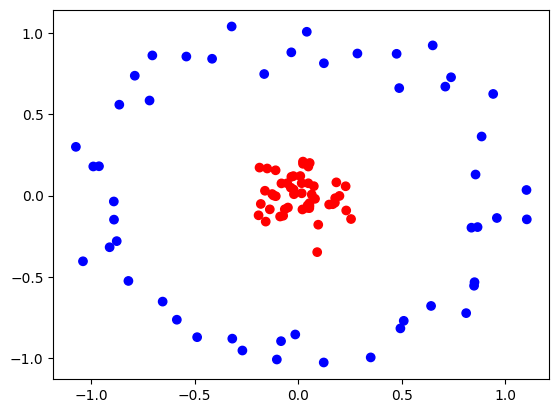

In [15]:
from sklearn.datasets._samples_generator import  make_circles
x,y=make_circles(100,factor=0.1,noise=0.1)
plt.scatter(x[:,0],x[:,1],c=y,cmap='bwr')

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [18]:
classifier=SVC(kernel='linear')
classifier.fit(x_train,y_train.ravel())
y_pred=classifier.predict(x_test)

In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.5

C:\Users\niraj\AppData\Local\Temp\ipykernel_109912\3975649218.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


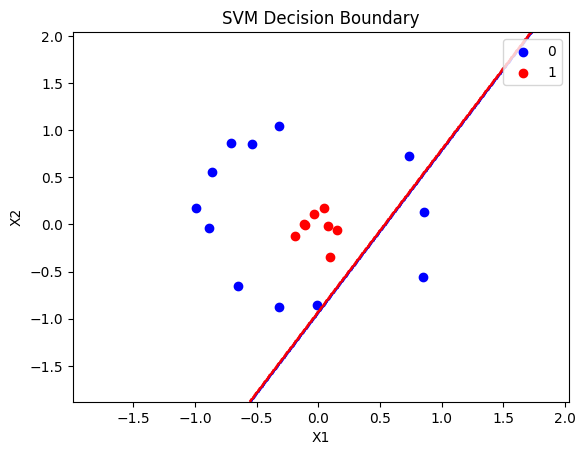

In [26]:
zero_one_colourmap = ListedColormap(('blue', 'red'))

def plot_decision_boundary(x, y, clf):
    x_set, y_set = x, y
    x1, x2 = np.meshgrid(
        np.arange(start=x_set[:, 0].min() - 1,
                  stop=max(x_set[:, 0].max(), x_set[:, 1].max()) + 1,
                  step=0.01),
        np.arange(start=x_set[:, 1].min() - 1,
                  stop=x_set[:, 1].max() + 1,
                  step=0.01)
    )

    plt.contour(x1, x2, clf.predict(np.array([x1.ravel(),
                                               x2.ravel()]).T).reshape(x1.shape),
                alpha=0.7,
                cmap=zero_one_colourmap)
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                    c=(zero_one_colourmap)(i), label=j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

plot_decision_boundary(x_test, y_test, classifier)


In [27]:
def plot_3d(x,y):
    r=np.exp(-(x**2).sum(1))
    ax=plt.subplot(projection='3d')
    ax.scatter3D(x[:,0],x[:,1],r,c=y,s=100,cmap='bwr')
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("y")
    return ax

<Axes3D: xlabel='x1', ylabel='x2', zlabel='y'>

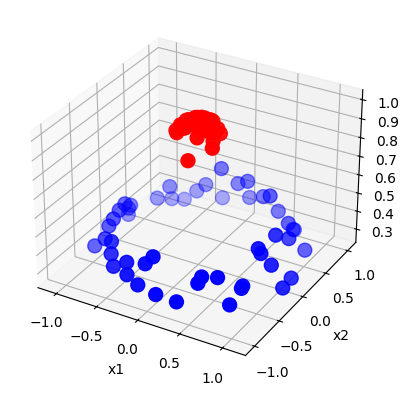

In [29]:
plot_3d(x,y)